# Week 1 — Networks

Degrees, distributions and components in the Wikipedia link network of 303 Marvel
characters. This notebook produces every figure and every number in
[the week 1 post](../weeks/week1/week1.html).

Run it top to bottom. It writes SVGs into `weeks/week1/figures/`, overwriting
what is already there — so the published figures are always the output of the
code in this file, not something detached from it.

**Course:** 02805 Social Graphs and Interactions, DTU.
**Data:** the frozen week-1 snapshot, 26 August 2026.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import marvel

marvel.use_site_style()

## 1. Loading the network

The one step worth being careful about. The edge list mentions only 286 of the
303 characters — 17 appear in neither column — so building the graph from edges
alone drops them silently. No exception, no warning, just a network that is
missing 6% of its nodes.

`marvel.load_graph()` adds the full node roster first. The assertion below is
the check that it worked.

In [2]:
G = marvel.load_graph()                 # directed
name = marvel.names(G)

n = G.number_of_nodes()
m_directed = G.number_of_edges()

print(f"nodes            {n}")
print(f"directed edges   {m_directed}")

assert n == 303, "node roster was not loaded before the edges"

nodes            303
directed edges   1784


### Checking against the course's published numbers

The course page states six quantities independently of us. Agreeing with all six
is the cheapest evidence available that the pipeline is right — it does not make
our *conclusions* right, but it rules out a broken load.

The two edge counts differ because some pairs link in both directions. Each of
those is two arrows but only one undirected pair.

In [3]:
U = G.to_undirected()
m_undirected = U.number_of_edges()
reciprocal = m_directed - m_undirected

avg_k = 2 * m_undirected / n
density = 2 * m_undirected / (n * (n - 1))

components = sorted(nx.connected_components(U), key=len, reverse=True)
isolates = [v for v in G.nodes() if G.degree(v) == 0]

checks = {
    "nodes":              (n,                    303),
    "directed edges":     (m_directed,           1784),
    "undirected pairs":   (m_undirected,         1434),
    "mean degree <k>":    (round(avg_k, 2),      9.47),
    "density":            (round(density, 3),    0.031),
    "giant component":    (len(components[0]),   277),
    "isolates":           (len(isolates),        17),
}

for label, (ours, published) in checks.items():
    flag = "OK " if ours == published else "MISMATCH"
    print(f"{flag} {label:<18} ours={ours:<8} course={published}")

print()
print(f"reciprocated pairs: {reciprocal}  "
      f"({m_directed} - {reciprocal} = {m_directed - reciprocal} undirected)")

OK  nodes              ours=303      course=303
OK  directed edges     ours=1784     course=1784
OK  undirected pairs   ours=1434     course=1434
OK  mean degree <k>    ours=9.47     course=9.47
OK  density            ours=0.031    course=0.031
OK  giant component    ours=277      course=277
OK  isolates           ours=17       course=17

reciprocated pairs: 350  (1784 - 350 = 1434 undirected)


## 2. Degree distributions

Four panels: in- and out-degree, each on linear and on log–log axes.

All four plot **k + 1** rather than k. A log axis cannot show zero, and 17
characters have no links at all — shifting keeps them in the picture instead of
quietly deleting them.

In [4]:
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

print(f"in-degree   max {max(in_deg.values()):>3}   zeros {sum(v == 0 for v in in_deg.values())}")
print(f"out-degree  max {max(out_deg.values()):>3}   zeros {sum(v == 0 for v in out_deg.values())}")
print()
print("Both means must be identical — every arrow leaves one article and arrives")
print("at another, so both are m/n by construction. If they disagree, it is a bug.")
print(f"  mean in  = {np.mean(list(in_deg.values())):.4f}")
print(f"  mean out = {np.mean(list(out_deg.values())):.4f}")

in-degree   max 106   zeros 58
out-degree  max  28   zeros 20

Both means must be identical — every arrow leaves one article and arrives
at another, so both are m/n by construction. If they disagree, it is a bug.
  mean in  = 5.8878
  mean out = 5.8878


### Validating the binning before trusting it

The binned curve is where a silent error would live: divide by the wrong width
and the plot still looks like a plot. The test is that where the bins are width
1, binning must reproduce the raw values exactly — averaging one integer with
itself is not an average.

In [5]:
print("in-degree, width-1 bins:")
ok_in = marvel.check_binning(in_deg)

print("\nout-degree, width-1 bins:")
ok_out = marvel.check_binning(out_deg)

assert ok_in and ok_out, "binning normalisation is wrong"
print("\nbinning validated")

in-degree, width-1 bins:
  u=1   binned=0.191419  raw=0.191419  OK
  u=2   binned=0.135314  raw=0.135314  OK
  u=3   binned=0.141914  raw=0.141914  OK
  u=4   binned=0.092409  raw=0.092409  OK
  u=5   binned=0.069307  raw=0.069307  OK
  u=6   binned=0.072607  raw=0.072607  OK
  u=7   binned=0.042904  raw=0.042904  OK

out-degree, width-1 bins:
  u=1   binned=0.066007  raw=0.066007  OK
  u=2   binned=0.102310  raw=0.102310  OK
  u=3   binned=0.122112  raw=0.122112  OK
  u=4   binned=0.132013  raw=0.132013  OK
  u=5   binned=0.102310  raw=0.102310  OK
  u=6   binned=0.069307  raw=0.069307  OK
  u=7   binned=0.052805  raw=0.052805  OK

binning validated


wrote weeks/week1/figures/in_linear.svg


wrote weeks/week1/figures/in_loglog.svg
wrote weeks/week1/figures/out_linear.svg


wrote weeks/week1/figures/out_loglog.svg


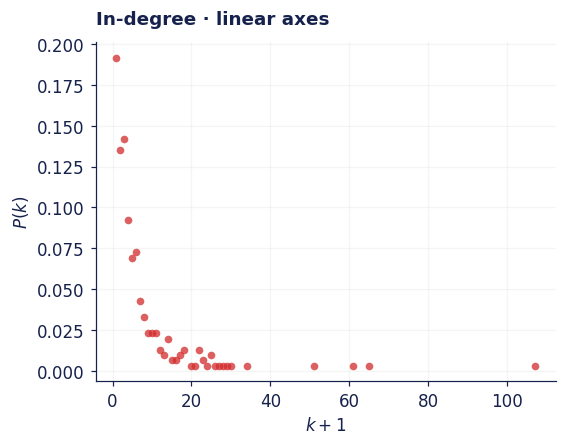

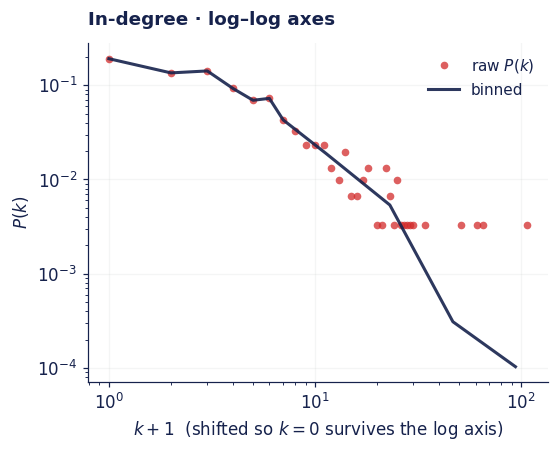

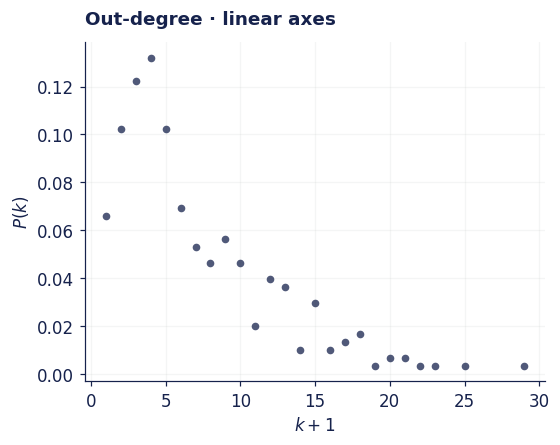

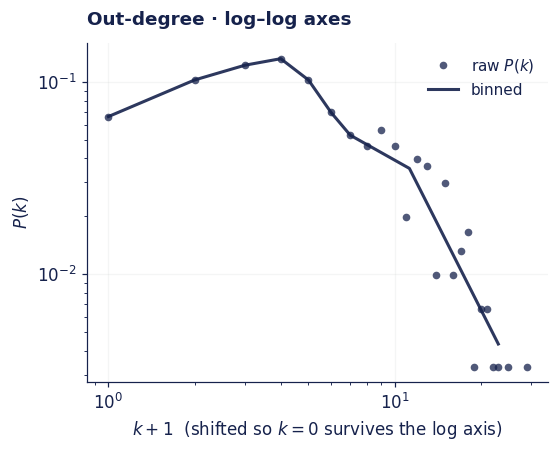

In [6]:
def degree_panel(degrees, kind, logaxes, filename, colour):
    ks, ps = marvel.distribution(degrees)

    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    if logaxes:
        ax.loglog(ks + 1, ps, "o", ms=5, color=colour, alpha=.75,
                  mec="none", label="raw $P(k)$")
        bx, by = marvel.log_binned(degrees)
        ax.loglog(bx, by, "-", lw=2, color=marvel.INK, alpha=.9, label="binned")
        ax.set_xlabel("$k+1$  (shifted so $k=0$ survives the log axis)")
        ax.legend(frameon=False, fontsize=10)
    else:
        ax.plot(ks + 1, ps, "o", ms=5, color=colour, alpha=.75, mec="none")
        ax.set_xlabel("$k+1$")

    ax.set_ylabel("$P(k)$")
    ax.set_title(f"{kind}-degree · {'log–log' if logaxes else 'linear'} axes",
                 loc="left", fontsize=12, fontweight="bold", pad=12)
    ax.grid(alpha=.18, color=marvel.RULE)
    marvel.save(fig, 1, filename)
    return fig

degree_panel(in_deg,  "In",  False, "in_linear",  marvel.RED)
degree_panel(in_deg,  "In",  True,  "in_loglog",  marvel.RED)
degree_panel(out_deg, "Out", False, "out_linear", marvel.INK)
degree_panel(out_deg, "Out", True,  "out_loglog", marvel.INK)
plt.show()

## 3. Hubs — fame versus talkativeness

In-degree and out-degree pick out almost completely different characters, and
the mechanism is the reason: an in-link is *conferred* by somebody else's
article, an out-link has to be *authored* into this one.

In [7]:
def leaderboard(degrees, other, label, k=5):
    top = sorted(degrees, key=degrees.get, reverse=True)[:k]
    print(f"{label:<28}{'':>4}{'this':>6}{'other':>7}")
    for v in top:
        print(f"  {name[v][:26]:<28}{'':>2}{degrees[v]:>6}{other[v]:>7}")
    return top

leaderboard(in_deg, out_deg, "Most linked TO")
print()
leaderboard(out_deg, in_deg, "Links out MOST")

a = np.array([in_deg[v] for v in G])
b = np.array([out_deg[v] for v in G])
print(f"\ncorrelation between in and out degree: {np.corrcoef(a, b)[0, 1]:.3f}")
print("High enough that the two are related; far too low to use one as a proxy")
print("for the other.")

Most linked TO                    this  other
  Spider-Man                       106      9
  Hulk                              64     10
  Wolverine (character)             60     17
  Doctor Strange                    50     17
  Deadpool                          33     19

Links out MOST                    this  other
  Betsy Braddock                    28      7
  Cloak and Dagger (characte        24     11
  Adam Warlock                      22      8
  Venom (character)                 21     17
  She-Hulk                          20     29

correlation between in and out degree: 0.496
High enough that the two are related; far too low to use one as a proxy
for the other.


wrote weeks/week1/figures/in_vs_out.svg


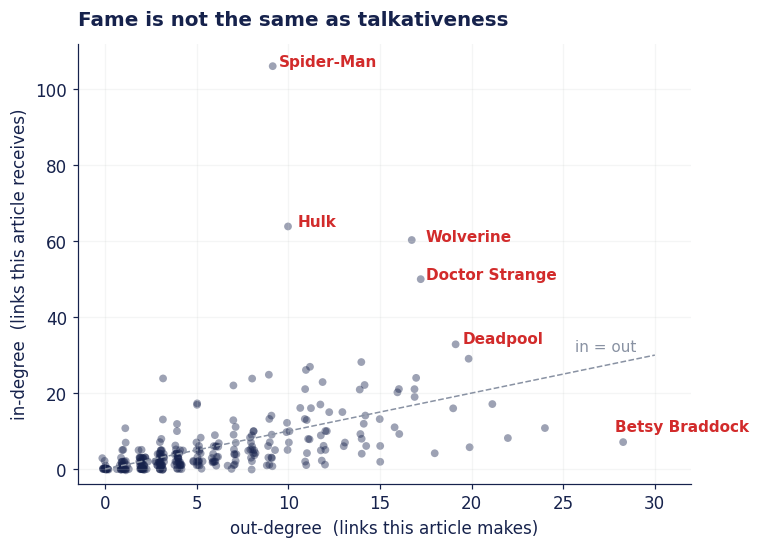

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))
jit = np.random.default_rng(4)

xs = np.array([out_deg[v] for v in G])
ys = np.array([in_deg[v] for v in G])
ax.scatter(xs + jit.normal(0, .12, len(xs)),
           ys + jit.normal(0, .12, len(ys)),
           s=26, color=marvel.INK, alpha=.42, edgecolors="none")

ax.plot([0, 30], [0, 30], "--", lw=1, color=marvel.MUTED)
ax.text(29, 31, "in = out", color=marvel.MUTED, fontsize=10, ha="right")

for label, dx, dy in [("Spider-Man", 6, 0), ("Hulk", 6, 0),
                      ("Wolverine (character)", 6, 0), ("Doctor Strange", 6, 0),
                      ("Betsy Braddock", -2, 7), ("Deadpool", 6, 0)]:
    v = next(x for x in G if name[x] == label)
    ax.annotate(name[v].replace(" (character)", ""), (out_deg[v], in_deg[v]),
                textcoords="offset points", xytext=(dx, dy), fontsize=10,
                color=marvel.RED, fontweight="bold")

ax.set_xlabel("out-degree  (links this article makes)")
ax.set_ylabel("in-degree  (links this article receives)")
ax.set_ylim(-4, 112)
ax.set_xlim(-1.5, 32)
ax.set_title("Fame is not the same as talkativeness", loc="left",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(alpha=.18, color=marvel.RULE)

marvel.save(fig, 1, "in_vs_out")
plt.show()

### The hub screen

On the page, the two leaderboards are an interactive screen: pick one of the five
most-linked-to characters (or, on the *Out* tab, the five who link out most) and
every link arrives at them — or leaves them — with the sentence that created it.

This cell writes everything that screen shows into `weeks/week1/data/hubs.js`, so
the screen is the output of this notebook like every figure is. For each link we
find the sentences in the source's article that name the target and keep the
first. Two rules keep that honest:

* the source's own names are blanked out first, so *Hulk 2099* talking about
  itself does not count as naming the Hulk;
* when two articles go by the same name (Spider-Man and the Mangaverse
  Spider-Man), we refuse to guess which sentences mean which and say so.

In [9]:
import json, re
import pandas as pd

pages = marvel.load_pages()
sents = {v: marvel.split_sentences(t) for v, t in pages.items()}

GENERIC = r"\s*\((?:character|characters|comics|Marvel Comics|Marvel Comics character)\)$"

def short(v):
    # display name: drop qualifiers that only exist to disambiguate Wikipedia titles
    return re.sub(GENERIC, "", name[v]).strip()

def base(v):
    return re.sub(r"\s*\(.*?\)$", "", name[v]).strip()

# The ten hubs are often written about under their civilian or other names.
ALSO = {"Spider-Man": ["Peter Parker"], "Hulk": ["Bruce Banner"],
        "Wolverine_(character)": ["Logan"], "Doctor_Strange": ["Stephen Strange", "Dr. Strange"],
        "Deadpool": ["Wade Wilson"], "Betsy_Braddock": ["Psylocke"],
        "She-Hulk": ["Jennifer Walters"]}

def names_of(v):
    return sorted({base(v), *ALSO.get(v, [])}, key=len, reverse=True)

def pattern(words):
    return re.compile(r"(?<![\w-])(" + "|".join(map(re.escape, words)) + r")(?![\w-])")

def naming(src, tgt):
    # sentences of src's article that name tgt, with src's own names blanked first
    own, want = pattern(names_of(src)), pattern(names_of(tgt))
    return [x for x in sents.get(src, []) if len(x) >= 40 and want.search(own.sub("_", x))]

length = {v: len(sents.get(v, [])) for v in G}
length_rank = {v: i + 1 for i, v in enumerate(sorted(G, key=lambda z: (-length[z], z)))}

top_in = sorted(in_deg, key=in_deg.get, reverse=True)[:5]     # same order as the leaderboards
top_out = sorted(out_deg, key=out_deg.get, reverse=True)[:5]

def hub_record(h, mode):
    nbrs = list(G.predecessors(h)) if mode == "in" else list(G.successors(h))
    links = []
    for v in nbrs:
        src, tgt = (v, h) if mode == "in" else (h, v)
        same = base(src) == base(tgt)
        found = [] if same else naming(src, tgt)
        first = found[0] if found else ""
        if len(first) > 280:
            first = first[:277].rsplit(" ", 1)[0] + "…"
        links.append({"id": v, "name": short(v), "in": in_deg[v], "out": out_deg[v],
                      "both": G.has_edge(tgt, src), "n": len(found), "same": same, "s": first})
    links.sort(key=lambda r: (-r["n"], r["name"]))
    return {"id": h, "name": short(h), "in": in_deg[h], "out": out_deg[h],
            "both": sum(r["both"] for r in links), "length": length[h],
            "length_rank": length_rank[h], "sentences": sum(r["n"] for r in links),
            "links": links}

HUBS = {"links_total": m_directed, "characters": n,
        "in": [hub_record(h, "in") for h in top_in],
        "out": [hub_record(h, "out") for h in top_out]}

target = marvel.ROOT / "weeks" / "week1" / "data" / "hubs.js"
target.parent.mkdir(exist_ok=True)
target.write_text(
    "// Written by notebooks/week1_marvel_network.ipynb -- do not edit by hand.\n"
    "// Quoted sentences come from the characters' Wikipedia articles, CC BY-SA 4.0.\n"
    "window.HUBS = " + json.dumps(HUBS, ensure_ascii=False, separators=(",", ":")) + ";\n",
    encoding="utf-8")
print(f"wrote {target.relative_to(marvel.ROOT)}  ({target.stat().st_size / 1024:.0f} KB)\n")

for mode in ("in", "out"):
    share = sum(h[mode] for h in HUBS[mode]) / m_directed
    print(f"top five by {mode}-degree hold {share:.1%} of all {m_directed:,} links")
    for h in HUBS[mode]:
        found = sum(1 for r in h["links"] if r["n"])
        print(f"  {h['name']:<18} in {h['in']:>3}  out {h['out']:>3}  both ways {h['both']:>3}  "
              f"article {h['length']:>3} sentences (#{h['length_rank']})  "
              f"sentence found for {found}/{len(h['links'])}")
    print()
covered = [r["n"] > 0 for m in ("in", "out") for h in HUBS[m] for r in h["links"]]
print(f"links with a sentence: {sum(covered)}/{len(covered)} ({sum(covered) / len(covered):.1%})")

wrote weeks/week1/data/hubs.js  (110 KB)

top five by in-degree hold 17.5% of all 1,784 links
  Spider-Man         in 106  out   9  both ways   9  article 463 sentences (#9)  sentence found for 104/106
  Hulk               in  64  out  10  both ways   9  article 341 sentences (#27)  sentence found for 64/64
  Wolverine          in  60  out  17  both ways  14  article 356 sentences (#24)  sentence found for 58/60
  Doctor Strange     in  50  out  17  both ways  10  article 381 sentences (#20)  sentence found for 47/50
  Deadpool           in  33  out  19  both ways  11  article 414 sentences (#15)  sentence found for 30/33

top five by out-degree hold 6.4% of all 1,784 links
  Betsy Braddock     in   7  out  28  both ways   7  article 597 sentences (#2)  sentence found for 28/28
  Cloak and Dagger   in  11  out  24  both ways   7  article 283 sentences (#36)  sentence found for 21/24
  Adam Warlock       in   8  out  22  both ways   5  article 323 sentences (#28)  sentence found for 22/

### Why these ten

The screen gives each character a short paragraph on *why* they collect (or
write) so many links. Every number in those paragraphs is printed here.

In [10]:
FIRST = re.compile(r"first appear|first appearance|debut|introduced", re.I)
ISSUE = re.compile(r"Spider-Man\s*#")
MAGIC = re.compile(r"magic|mystic|sorcer|occult|supernatural|demon", re.I)
XTEAMS = re.compile(r"X-Men|X-Force|X-Factor|Excalibur|mutant", re.I)
labels = pd.read_csv(marvel.DATA / "derived" / "week5_edge_labels.tsv", sep="\t", skiprows=2)
LABEL = {(r.source, r.target): r.label for r in labels.itertuples(index=False)}

def rec(h):
    return next(x for m in ("in", "out") for x in HUBS[m] if x["id"] == h)

print("RECEIVERS")
for h in top_in:
    r, nb = rec(h), list(G.predecessors(h))
    firsts = [v for v in nb if any(FIRST.search(x) for x in naming(v, h))]
    nd = [in_deg[v] for v in nb]
    fights = sum(LABEL.get((v, h)) == "enemy" for v in nb)
    print(f"\n{r['name']}: {r['in']} in, {r['out']} out, {r['both']} both ways "
          f"({r['both'] / r['in']:.0%} of the in-links)")
    print(f"  sentences naming them: {r['sentences']:,} across "
          f"{sum(1 for x in r['links'] if x['n'])} articles, median "
          f"{np.median([x['n'] for x in r['links']]):g} per article")
    print(f"  most: " + ", ".join(f"{x['name']} {x['n']}" for x in r["links"][:4]))
    print(f"  first-appearance sentence names them: {len(firsts)}")
    print(f"  linkers with 20+ in-links of their own: {sum(x >= 20 for x in nd)}   "
          f"with none: {sum(x == 0 for x in nd)}")
    print(f"  week 5 labelled the link a fight: {fights} ({fights / r['in']:.0%})")

sm_first = [v for v in G.predecessors("Spider-Man")
            if any(FIRST.search(x) and ISSUE.search(x) for x in naming(v, "Spider-Man"))]
print(f"\nSpider-Man: first-appearance sentences that give a Spider-Man issue number: {len(sm_first)}")
print("  linkers named after him:",
      [short(v) for v in G.predecessors("Spider-Man") if "Spider" in name[v]])
sm_text = " ".join(sents["Spider-Man"])
for who in ["Mary Jane", "Green Goblin", "Aunt May", "Doctor Octopus"]:
    in_net = any(who.lower() in name[v].lower() for v in G)
    print(f"  his article names {who} {len(re.findall(re.escape(who), sm_text))} times "
          f"(a node in this network: {in_net})")
print("Hulk: linkers carrying his name:",
      [short(v) for v in G.predecessors("Hulk") if "Hulk" in name[v]])
ds = [v for v in G.predecessors("Doctor_Strange")
      if any(MAGIC.search(x) for x in naming(v, "Doctor_Strange"))]
print(f"Doctor Strange: linkers whose sentences about him mention magic and the like: {len(ds)}")
print("  among them:", ", ".join(sorted(short(v) for v in ds)))
wv = [v for v in G.predecessors("Wolverine_(character)")
      if any(XTEAMS.search(x) for x in naming(v, "Wolverine_(character)"))]
print(f"Wolverine: linkers whose sentences about him mention the X-teams or mutants: {len(wv)}")
print("Deadpool: linkers who borrowed his name:",
      [short(v) for v in G.predecessors("Deadpool") if "pool" in name[v].lower()])

print("\nWRITERS")
for h in top_out:
    r, nb = rec(h), list(G.successors(h))
    print(f"\n{r['name']}: {r['out']} out, {r['in']} in, {r['both']} both ways; "
          f"article {r['length']} sentences, #{r['length_rank']} of {n}")
    print(f"  median in-degree of the characters they link to: "
          f"{np.median([in_deg[v] for v in nb]):g} (network median {np.median(list(in_deg.values())):g})")
    print(f"  links resting on a single sentence: {sum(1 for x in r['links'] if x['n'] == 1)}")
    print(f"  most: " + ", ".join(f"{x['name']} {x['n']}" for x in r["links"][:4]))
bx = [v for v in G.successors("Betsy_Braddock")
      if any(XTEAMS.search(x) for x in naming("Betsy_Braddock", v))]
print(f"\nBetsy Braddock: links whose sentences mention the X-teams or mutants: {len(bx)}")
cd = sents["Cloak_and_Dagger_(characters)"]
print(f"Cloak and Dagger: sentences naming Cloak {sum('Cloak' in x for x in cd)}, "
      f"Dagger {sum('Dagger' in x for x in cd)}")
HOST = re.compile(r"\bhosts?\b", re.I)
print(f"Venom: sentences mentioning a host: {sum(bool(HOST.search(x)) for x in sents['Venom_(character)'])}")
in_rank = sorted(in_deg, key=in_deg.get, reverse=True)
print(f"She-Hulk ranks #{in_rank.index('She-Hulk') + 1} by in-degree, behind "
      f"{short(in_rank[in_rank.index('She-Hulk') - 1])}")
tied = [short(v) for v in G if out_deg[v] == out_deg[top_out[-1]]]
print(f"tied at {out_deg[top_out[-1]]} out-links: {tied}")

RECEIVERS

Spider-Man: 106 in, 9 out, 9 both ways (8% of the in-links)
  sentences naming them: 1,283 across 104 articles, median 4 per article
  most: Venom 154, Eddie Brock 140, Black Cat 119, Morbius 62
  first-appearance sentence names them: 33
  linkers with 20+ in-links of their own: 13   with none: 10
  week 5 labelled the link a fight: 36 (34%)

Hulk: 64 in, 10 out, 9 both ways (14% of the in-links)
  sentences naming them: 417 across 64 articles, median 2.5 per article
  most: She-Hulk 71, Abomination 69, Hercules 29, Devil Hulk 23
  first-appearance sentence names them: 12
  linkers with 20+ in-links of their own: 6   with none: 2
  week 5 labelled the link a fight: 32 (50%)



Wolverine: 60 in, 17 out, 14 both ways (23% of the in-links)
  sentences naming them: 291 across 58 articles, median 2.5 per article
  most: Betsy Braddock 35, Jubilee 29, Northstar 19, Deadpool 17
  first-appearance sentence names them: 6
  linkers with 20+ in-links of their own: 14   with none: 7
  week 5 labelled the link a fight: 14 (23%)

Doctor Strange: 50 in, 17 out, 10 both ways (20% of the in-links)
  sentences naming them: 136 across 47 articles, median 2 per article
  most: Scarlet Witch 14, Adam Warlock 9, Ghost Rider (Johnny Blaze) 8, Jericho Drumm 8
  first-appearance sentence names them: 5
  linkers with 20+ in-links of their own: 8   with none: 3
  week 5 labelled the link a fight: 9 (18%)

Deadpool: 33 in, 19 out, 11 both ways (33% of the in-links)
  sentences naming them: 159 across 30 articles, median 3 per article
  most: Bob, Agent of Hydra 27, Gwenpool 17, Cable 13, Hit-Monkey 13
  first-appearance sentence names them: 3
  linkers with 20+ in-links of their own: 


Spider-Man: first-appearance sentences that give a Spider-Man issue number: 15
  linkers named after him: ['Scarlet Spider', 'Spider-Bitch (Ashley Barton)', 'Spider-Girl', 'Spider-Man (Marvel Mangaverse)', 'Spider-Man Noir', 'Spider-UK', 'Spider-Woman', 'Spider-Woman (Gwen Stacy)', 'Steel Spider']
  his article names Mary Jane 27 times (a node in this network: False)
  his article names Green Goblin 17 times (a node in this network: False)
  his article names Aunt May 15 times (a node in this network: False)
  his article names Doctor Octopus 13 times (a node in this network: False)
Hulk: linkers carrying his name: ['Devil Hulk', 'Hulk 2099', 'Hulkling', 'She-Hulk', 'She-Hulk (Lyra)']
Doctor Strange: linkers whose sentences about him mention magic and the like: 21
  among them: Adam Warlock, Betsy Braddock, Black Knight, Black Rider, Blade, Bob, Agent of Hydra, Darkdevil, Doctor Druid, Ghost Rider, Ghost Rider (Johnny Blaze), Jericho Drumm, Jessica Jones, Moon Knight, Moondragon, Morb

## 4. Triangles, and whether 3% density explains them

Degree says how many links a character has. Clustering says whether those links
know each other: of all the connected triples A–B–C, what share are closed into a
triangle by a third link A–C?

Two numbers, and they are not the same thing. **Transitivity** is global — three
times the triangles over the number of connected triples, one number for the whole
network, dominated by the high-degree nodes because they sit in most of the
triples. **Average clustering** computes the share per character and then averages
the characters, which gives Spider-Man and a nine-node side cast equal say.
Reporting one and calling it "the clustering" hides the difference.

In [11]:
deg = dict(U.degree())
cc = nx.clustering(U)

triangles = sum(nx.triangles(U).values()) // 3
triads = sum(d * (d - 1) // 2 for _, d in U.degree())
transitivity = nx.transitivity(U)
avg_c = nx.average_clustering(U)

print(f"triangles                  {triangles:>9,}")
print(f"connected triples          {triads:>9,}")
print(f"transitivity  3T/triples   {transitivity:>9.4f}")
print(f"  recomputed by hand       {3 * triangles / triads:>9.4f}")
print(f"average clustering <C>     {avg_c:>9.4f}")
print(f"density, for comparison    {density:>9.4f}")

# Clustering is undefined for a node with fewer than two neighbours -- there is
# no triple to close. networkx records 0, which is not the same claim, so say
# what the average looks like without them.
elig = [v for v in U if deg[v] >= 2]
print(f"\ndegree < 2, clustering undefined : {len(U) - len(elig)} characters (recorded as 0)")
print(f"<C> over the {len(elig)} where it is defined : "
      f"{np.mean([cc[v] for v in elig]):.4f}")

# a callback to the components section: the Morituri island is nine characters
# with 13 links among them, and almost everything they could close, they close
isl = U.subgraph(components[1])
print(f"\nthe nine-character island: {isl.number_of_edges()} links, "
      f"<C> = {nx.average_clustering(isl):.3f}")

triangles                      1,839
connected triples             30,231
transitivity  3T/triples      0.1825
  recomputed by hand          0.1825
average clustering <C>        0.3075
density, for comparison       0.0313

degree < 2, clustering undefined : 35 characters (recorded as 0)
<C> over the 268 where it is defined : 0.3476

the nine-character island: 13 links, <C> = 0.504


### Two null models, because 18% means nothing on its own

A clustering coefficient is only interesting against the question *compared with
what?*, and there are two different compared-with-whats.

**A random graph with the same number of nodes and edges** (Erdős–Rényi). Every
pair is linked with the same probability, so the chance that a triple closes is
just that probability — the clustering of an ER graph is its density, about 3.1%.
This is the weak null: it knows how big the network is and nothing else.

**The same network with its edges shuffled, keeping every degree** (double-edge
swaps). This one is the honest comparison. Heavy-tailed degree sequences produce
triangles for free: Spider-Man has 106 neighbours, and some of those 106 are bound
to link to each other whether or not anything social is going on. Beating this
null means the triangles are *not* a side effect of a few characters being
enormous.

500 replicates of each, cached so the notebook stays quick to re-run.

In [12]:
# One ER graph and one degree-preserving rewiring of U per replicate.
def null_battery(reps=500):
    rows = []
    for i in range(reps):
        R_er = nx.gnm_random_graph(n, m_undirected, seed=1000 + i)
        R_rw = marvel.rewired(U, seed=2000 + i)
        rows.append({
            "er_transitivity":  nx.transitivity(R_er),
            "er_clustering":    nx.average_clustering(R_er),
            "er_assortativity": nx.degree_assortativity_coefficient(R_er),
            "er_triangles":     sum(nx.triangles(R_er).values()) // 3,
            "rw_transitivity":  nx.transitivity(R_rw),
            "rw_clustering":    nx.average_clustering(R_rw),
            "rw_assortativity": nx.degree_assortativity_coefficient(R_rw),
            "rw_triangles":     sum(nx.triangles(R_rw).values()) // 3,
        })
    return rows

nulls = marvel.cached("week1_clustering_nulls", null_battery)
NUL = {k: np.array([r[k] for r in nulls]) for k in nulls[0]}

# the sanity check with a known answer: ER clustering must come out at the density
print(f"ER transitivity {NUL['er_transitivity'].mean():.4f} vs density {density:.4f}"
      f"  (theory says equal)")

loaded 500 cached replicates from data/derived/week1_clustering_nulls.jsonl
ER transitivity 0.0314 vs density 0.0313  (theory says equal)


In [13]:
r_undirected = nx.degree_assortativity_coefficient(U)

def compare(label, real, er, rw, fmt="{:.4f}"):
    print(f"{label:<16}{fmt.format(real):>10}"
          f"{fmt.format(er.mean()):>11}{marvel.zscore(real, er):>8.1f}"
          f"{fmt.format(rw.mean()):>11}{marvel.zscore(real, rw):>8.1f}")

print(f"{'':<16}{'Marvel':>10}{'ER':>11}{'z':>8}{'rewired':>11}{'z':>8}")
compare("triangles",      triangles,     NUL["er_triangles"],     NUL["rw_triangles"], "{:.0f}")
compare("transitivity",   transitivity,  NUL["er_transitivity"],  NUL["rw_transitivity"])
compare("avg clustering", avg_c,         NUL["er_clustering"],    NUL["rw_clustering"])
compare("assortativity",  r_undirected,  NUL["er_assortativity"], NUL["rw_assortativity"])

print("\nfull range over the 500 replicates")
for k in ["transitivity", "clustering", "assortativity"]:
    print(f"  {k:<14} ER [{NUL['er_' + k].min():+.4f}, {NUL['er_' + k].max():+.4f}]"
          f"    rewired [{NUL['rw_' + k].min():+.4f}, {NUL['rw_' + k].max():+.4f}]")

print(f"\ntransitivity is {transitivity / NUL['er_transitivity'].mean():.1f}x the ER null "
      f"and {transitivity / NUL['rw_transitivity'].mean():.2f}x the degree-preserving one")

                    Marvel         ER       z    rewired       z
triangles             1839        142   153.0       1157    15.3
transitivity        0.1825     0.0314    62.9     0.1148    15.3
avg clustering      0.3075     0.0314    99.4     0.1432    20.0
assortativity      -0.0977    -0.0067    -3.6    -0.1205     2.0

full range over the 500 replicates
  transitivity   ER [+0.0251, +0.0404]    rewired [+0.1003, +0.1300]
  clustering     ER [+0.0240, +0.0409]    rewired [+0.1196, +0.1736]
  assortativity  ER [-0.0791, +0.0699]    rewired [-0.1587, -0.0883]

transitivity is 5.8x the ER null and 1.59x the degree-preserving one


wrote weeks/week1/figures/clustering.svg


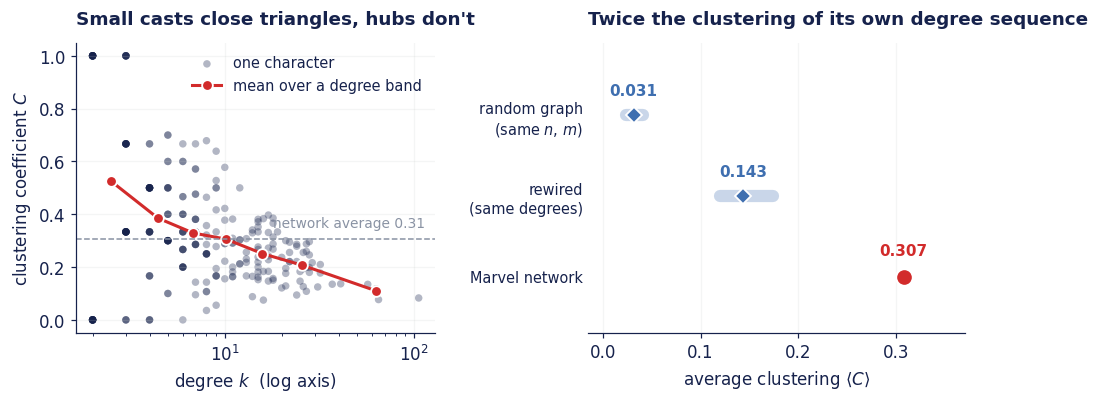

mean clustering by degree band
  k   2-3    n= 57   mean C = 0.526
  k   4-5    n= 46   mean C = 0.386
  k   6-8    n= 54   mean C = 0.329
  k   9-12   n= 33   mean C = 0.306
  k  13-20   n= 43   mean C = 0.251
  k  21-40   n= 30   mean C = 0.207
  k  41-110  n=  5   mean C = 0.110

the five biggest hubs close very little
  Spider-Man       k= 106   C = 0.083
  Hulk             k=  65   C = 0.077
  Wolverine        k=  63   C = 0.118
  Doctor Strange   k=  57   C = 0.135
  Deadpool         k=  41   C = 0.137


In [14]:
# The nulls' colour is the blue validated against the site red for colour-blind
# separation in week 5; the real network is always the red marker.
BLUE = "#3F6FB0"
BANDS = [(2, 3), (4, 5), (6, 8), (9, 12), (13, 20), (21, 40), (41, 110)]


# Mean of `values` within each degree band, plotted at the band's geometric mean.
def banded_mean(values, bands=BANDS, kmin=2):
    xs, ys = [], []
    for lo, hi in bands:
        vs = [v for v in U if kmin <= deg[v] and lo <= deg[v] <= hi]
        if not vs:
            continue
        xs.append(float(np.exp(np.mean([np.log(deg[v]) for v in vs]))))
        ys.append(float(np.mean([values[v] for v in vs])))
    return np.array(xs), np.array(ys)


# Three rows: the two nulls as the full min-max range of the 500 replicates with
# a diamond at the mean, and the real network as a red dot. Every value carries
# its own printed number, so the figure never depends on telling colours apart.
def null_panel(ax, real, er, rw, title, fmt="{:.3f}", zero=False):
    for y, arr in [(2, er), (1, rw)]:
        ax.plot([arr.min(), arr.max()], [y, y], "-", color=BLUE, lw=8, alpha=.28,
                solid_capstyle="round")
        ax.plot([arr.mean()], [y], "D", ms=7.5, color=BLUE, mec="white", mew=1.2)
        ax.annotate(fmt.format(arr.mean()), (arr.mean(), y), textcoords="offset points",
                    xytext=(0, 13), ha="center", fontsize=10, color=BLUE, fontweight="bold")
    ax.plot([real], [0], "o", ms=11, color=marvel.RED, mec="white", mew=1.4)
    ax.annotate(fmt.format(real), (real, 0), textcoords="offset points",
                xytext=(0, 14), ha="center", fontsize=10, color=marvel.RED, fontweight="bold")
    if zero:
        ax.axvline(0, lw=1, ls="--", color=marvel.MUTED)
        ax.text(0, 2.52, "no preference", ha="center", fontsize=8.5, color=marvel.MUTED)
    ax.set_yticks([2, 1, 0])
    ax.set_yticklabels(["random graph\n(same $n$, $m$)", "rewired\n(same degrees)",
                        "Marvel network"], fontsize=9.5, linespacing=1.3)
    ax.set_ylim(-.7, 2.9)
    ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="x", alpha=.18, color=marvel.RULE)
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold", pad=12)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.05]})

k2 = [v for v in U if deg[v] >= 2]
ax1.scatter([deg[v] for v in k2], [cc[v] for v in k2], s=24, color=marvel.INK,
            alpha=.33, edgecolors="none", label="one character")
bx, by = banded_mean(cc)
ax1.plot(bx, by, "-o", lw=2, ms=7, color=marvel.RED, mec="white", mew=1.2,
         label="mean over a degree band")
ax1.axhline(avg_c, lw=1, ls="--", color=marvel.MUTED)
ax1.text(115, avg_c + .045, f"network average {avg_c:.2f}", fontsize=9,
         color=marvel.MUTED, ha="right")
ax1.set_xscale("log")
ax1.set_xlabel("degree $k$  (log axis)")
ax1.set_ylabel("clustering coefficient $C$")
ax1.set_title("Small casts close triangles, hubs don't", loc="left",
              fontsize=12, fontweight="bold", pad=12)
ax1.legend(frameon=False, fontsize=9.5, loc="upper right")
ax1.grid(alpha=.18, color=marvel.RULE)

null_panel(ax2, avg_c, NUL["er_clustering"], NUL["rw_clustering"],
           "Twice the clustering of its own degree sequence")
ax2.set_xlabel("average clustering $\\langle C \\rangle$")
ax2.set_xlim(-.015, .37)

fig.tight_layout(w_pad=2)
marvel.save(fig, 1, "clustering")
plt.show()

print("mean clustering by degree band")
for lo, hi in BANDS:
    vs = [v for v in U if lo <= deg[v] <= hi]
    print(f"  k {lo:>3}-{hi:<3}  n={len(vs):>3}   mean C = {np.mean([cc[v] for v in vs]):.3f}")

print("\nthe five biggest hubs close very little")
for v in sorted(U, key=lambda z: -deg[z])[:5]:
    print(f"  {name[v].replace(' (character)', ''):<16} k={deg[v]:>4}   C = {cc[v]:.3f}")


## 5. Do hubs link to hubs?

Back to the hubs for a moment. Degree assortativity *r* is the correlation between
the degrees at the two ends of a link: positive means hubs pair with hubs,
negative means hubs pair with the obscure.

The trap is that *r* cannot be read on its own either. A simple network with a
106-degree node has no choice but to look disassortative — there is only one
Spider-Man, so his 106 links have to go to characters smaller than him. The
rewired null from the previous section is the fix: it has exactly the same
degrees, so whatever disassortativity the degree sequence forces shows up there
too.

In [15]:
knn = nx.average_neighbor_degree(U)
linked = [v for v in U if deg[v] >= 1]

print(f"undirected r                  {r_undirected:+.4f}")
print(f"  giant component only        {nx.degree_assortativity_coefficient(marvel.giant_component(G)):+.4f}")
print(f"  ER null        mean         {NUL['er_assortativity'].mean():+.4f}"
      f"   z = {marvel.zscore(r_undirected, NUL['er_assortativity']):+.1f}")
print(f"  rewired null   mean         {NUL['rw_assortativity'].mean():+.4f}"
      f"   z = {marvel.zscore(r_undirected, NUL['rw_assortativity']):+.1f}")

worse = int(np.sum(NUL["rw_assortativity"] >= r_undirected))
print(f"\nrewired replicates at least as assortative as the real network: "
      f"{worse}/{len(nulls)}")

print("\ndirected variants -- which end of the arrow is correlated with which")
for x in ("out", "in"):
    for y in ("out", "in"):
        print(f"  r({x:<3} of source, {y:<3} of target) = "
              f"{nx.degree_assortativity_coefficient(G, x=x, y=y):+.4f}")

print("\naverage neighbour degree by band")
for lo, hi in [(1, 1)] + BANDS:
    vs = [v for v in U if lo <= deg[v] <= hi]
    if vs:
        print(f"  k {lo:>3}-{hi:<3}  n={len(vs):>3}   <k_nn> = "
              f"{np.mean([knn[v] for v in vs]):>6.1f}")
print(f"\n  all linked characters       <k_nn> = {np.mean([knn[v] for v in linked]):.1f}")

undirected r                  -0.0977
  giant component only        -0.1051
  ER null        mean         -0.0067   z = -3.6
  rewired null   mean         -0.1205   z = +2.0

rewired replicates at least as assortative as the real network: 7/500

directed variants -- which end of the arrow is correlated with which
  r(out of source, out of target) = +0.1075
  r(out of source, in  of target) = -0.0227
  r(in  of source, out of target) = +0.1002
  r(in  of source, in  of target) = -0.0067

average neighbour degree by band
  k   1-1    n= 18   <k_nn> =   45.5
  k   2-3    n= 57   <k_nn> =   22.0
  k   4-5    n= 46   <k_nn> =   25.1
  k   6-8    n= 54   <k_nn> =   21.4
  k   9-12   n= 33   <k_nn> =   24.7
  k  13-20   n= 43   <k_nn> =   23.2
  k  21-40   n= 30   <k_nn> =   21.4
  k  41-110  n=  5   <k_nn> =   17.3

  all linked characters       <k_nn> = 24.2


wrote weeks/week1/figures/assortativity.svg


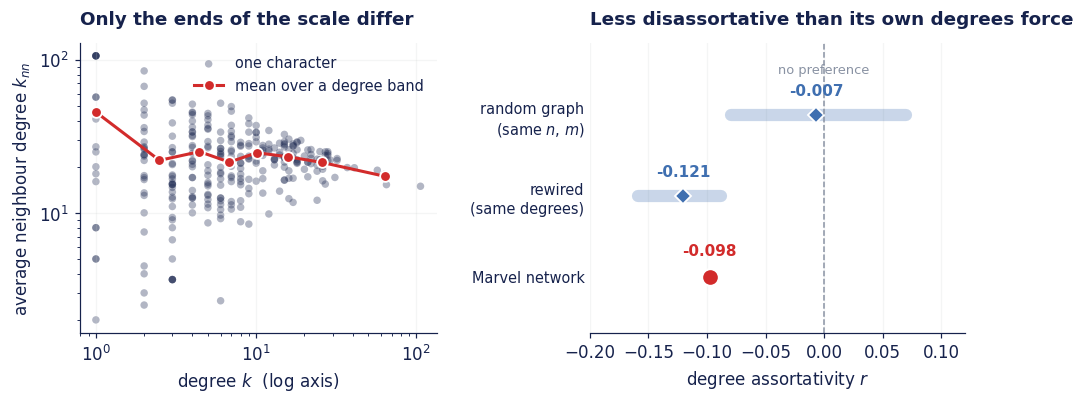

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.8),
                               gridspec_kw={"width_ratios": [1, 1.05]})

ax1.scatter([deg[v] for v in linked], [knn[v] for v in linked], s=24,
            color=marvel.INK, alpha=.33, edgecolors="none", label="one character")
bx, by = banded_mean(knn, bands=[(1, 1)] + BANDS, kmin=1)
ax1.plot(bx, by, "-o", lw=2, ms=7, color=marvel.RED, mec="white", mew=1.2,
         label="mean over a degree band")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("degree $k$  (log axis)")
ax1.set_ylabel("average neighbour degree $k_{nn}$")
ax1.set_title("Only the ends of the scale differ", loc="left",
              fontsize=12, fontweight="bold", pad=12)
ax1.legend(frameon=False, fontsize=9.5, loc="upper right")
ax1.grid(alpha=.18, color=marvel.RULE)

null_panel(ax2, r_undirected, NUL["er_assortativity"], NUL["rw_assortativity"],
           "Less disassortative than its own degrees force", fmt="{:+.3f}", zero=True)
ax2.set_xlabel("degree assortativity $r$")
ax2.set_xlim(-.20, .12)

fig.tight_layout(w_pad=2)
marvel.save(fig, 1, "assortativity")
plt.show()

## 6. Components

19 components: one of 277, one of 9, and seventeen of one.

The nine is the find of the week. We did not know the series existed — we found
a disconnected clique and went to look up who they were.

In [17]:
giant, island = components[0], components[1]

print(f"components: {len(components)}   sizes: {[len(c) for c in components][:3]} ...")
print(f"\nthe island ({len(island)} characters):")
for v in sorted(island, key=lambda z: name[z]):
    print(f"   {name[v]}")

print(f"\nthe {len(isolates)} isolates:")
print("  " + ", ".join(sorted(name[v] for v in isolates)))

components: 19   sizes: [277, 9, 1] ...

the island (9 characters):
   Backhand (character)
   Blackthorn (character)
   Radian (Morituri)
   Scaredycat
   Scatterbrain (Morituri)
   Shear (character)
   Snapdragon (Morituri)
   Toxyn
   Vyking

the 17 isolates:
  Baymax, Bird-Brain (Marvel Comics), Black Fox (Robert Paine), Brain Drain (character), Breeze Barton, Captain Midlands, Charcoal (comics), Father Time (Marvel Comics), Happy Sam Sawyer, Hellfire (J. T. Slade), Illuminator (Marvel Comics), Miracleman (character), Ogre (Marvel Comics), Sean and Chris, Solarman, Super Rabbit, Yo-Yo Rodriguez


### Drawing all 303

The giant component gets a force-directed layout. The isolates and the island
do **not** — a force layout has nothing to say about a node with no edges, so it
would scatter them arbitrarily and invite the reader to find meaning in where
they landed. We place them deliberately instead, and say so in the caption.

wrote weeks/week1/figures/network.svg


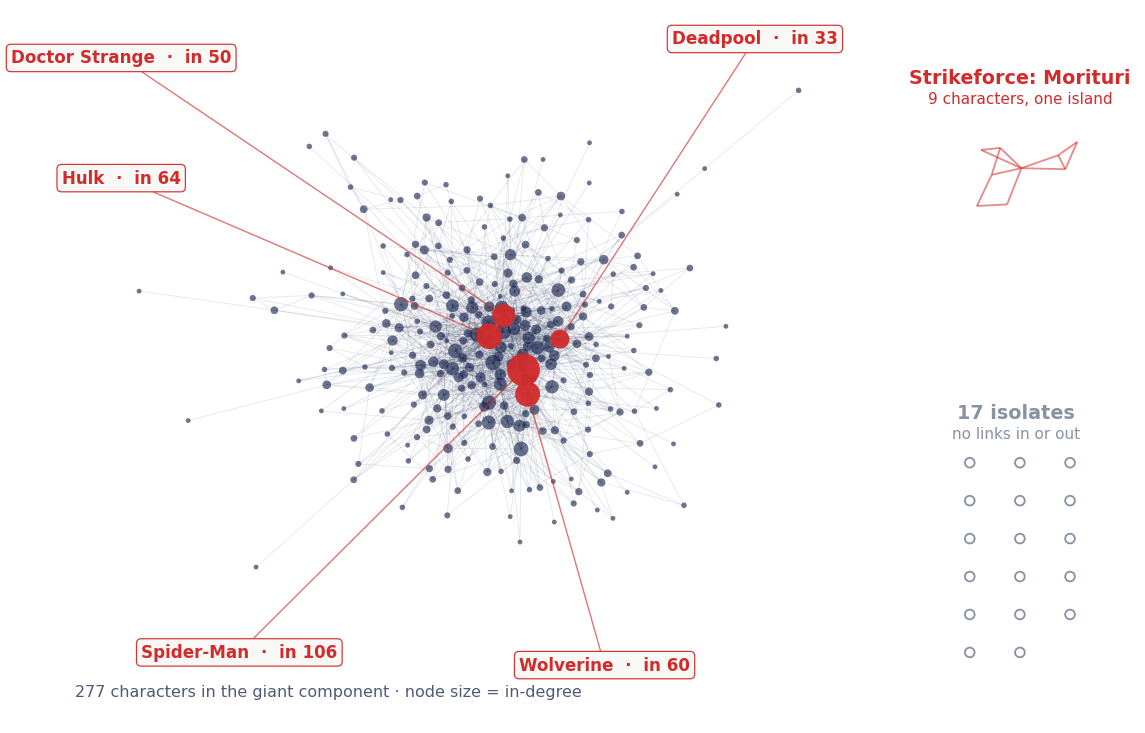

In [18]:
pos = nx.spring_layout(U.subgraph(giant), seed=17, k=.33, iterations=800)
P = np.array([pos[v] for v in giant])
P -= P.mean(0)
P /= np.abs(P).max()
pos = {v: P[i] for i, v in enumerate(giant)}

ip = nx.spring_layout(U.subgraph(island), seed=2, k=.6)
IP = np.array([ip[v] for v in island])
IP -= IP.mean(0)
IP /= np.abs(IP).max()
for i, v in enumerate(island):
    pos[v] = IP[i] * .16 + np.array([1.46, .55])

for i, v in enumerate(sorted(isolates, key=lambda z: name[z])):
    pos[v] = np.array([1.32 + (i % 3) * .14, -.38 - (i // 3) * .12])

hubs = sorted(giant, key=lambda v: in_deg[v], reverse=True)[:5]
rest = [v for v in giant if v not in hubs]

fig, ax = plt.subplots(figsize=(12.6, 8.4))
nx.draw_networkx_edges(U.subgraph(giant), pos, ax=ax,
                       edge_color=marvel.INK, alpha=.10, width=.6)
nx.draw_networkx_edges(U.subgraph(island), pos, ax=ax,
                       edge_color=marvel.RED, alpha=.55, width=1.2)
nx.draw_networkx_nodes(U.subgraph(giant), pos, nodelist=rest, ax=ax,
                       node_size=[10 + 3.2 * in_deg[v] for v in rest],
                       node_color=marvel.INK, alpha=.62, linewidths=0)
nx.draw_networkx_nodes(U.subgraph(giant), pos, nodelist=hubs, ax=ax,
                       node_size=[16 + 4.2 * in_deg[v] for v in hubs],
                       node_color=marvel.RED, alpha=.95, linewidths=0)
nx.draw_networkx_nodes(G.subgraph(isolates), pos, ax=ax, node_size=40,
                       node_color="none", edgecolors=marvel.MUTED, linewidths=1.2)

anchors = {"Spider-Man": (-.72, -.98), "Hulk": (-1.05, .52),
           "Wolverine (character)": (.30, -1.02),
           "Doctor Strange": (-1.05, .90), "Deadpool": (.72, .96)}
for label, xy in anchors.items():
    v = next(x for x in G if name[x] == label)
    short = name[v].replace(" (character)", "")
    ax.annotate(f"{short}  ·  in {in_deg[v]}", pos[v], xytext=xy, fontsize=11,
                fontweight="bold", color=marvel.RED, ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color=marvel.RED, lw=.9,
                                alpha=.65, shrinkA=0, shrinkB=6),
                bbox=dict(boxstyle="round,pad=.28", fc=marvel.CARD,
                          ec=marvel.RED, lw=.8, alpha=.95))

ax.text(1.46, .82, "Strikeforce: Morituri", color=marvel.RED,
        fontsize=12.5, fontweight="bold", ha="center")
ax.text(1.46, .755, "9 characters, one island", color=marvel.RED,
        fontsize=10, ha="center")
ax.text(1.45, -.24, "17 isolates", color=marvel.MUTED,
        fontsize=12.5, fontweight="bold", ha="center")
ax.text(1.45, -.305, "no links in or out", color=marvel.MUTED,
        fontsize=10, ha="center")
ax.text(-1.18, -1.12,
        "277 characters in the giant component · node size = in-degree",
        color=marvel.INK, fontsize=10.5, ha="left", alpha=.75)

ax.set_xlim(-1.22, 1.78)
ax.set_ylim(-1.20, 1.05)
ax.axis("off")

marvel.save(fig, 1, "network")
plt.show()

wrote weeks/week1/figures/morituri.svg


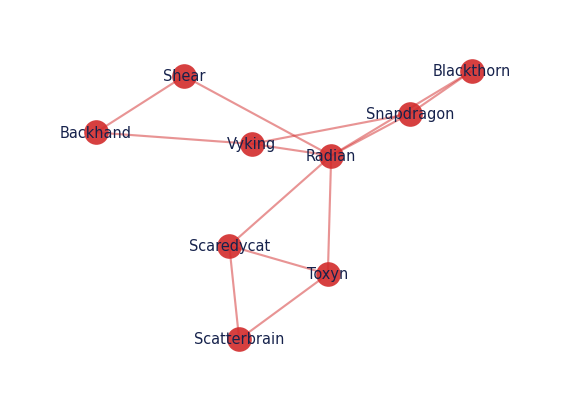

In [19]:
sub = U.subgraph(island)
p2 = nx.spring_layout(sub, seed=5, k=.85)

fig, ax = plt.subplots(figsize=(6.4, 4.6))
nx.draw_networkx_edges(sub, p2, ax=ax, edge_color=marvel.RED, alpha=.5, width=1.4)
nx.draw_networkx_nodes(sub, p2, ax=ax, node_size=260,
                       node_color=marvel.RED, alpha=.9, linewidths=0)
nx.draw_networkx_labels(
    sub, p2,
    {v: name[v].replace(" (character)", "").replace(" (Morituri)", "") for v in sub},
    font_size=9.5, ax=ax, font_color=marvel.INK)
ax.axis("off")
ax.margins(.16)

marvel.save(fig, 1, "morituri")
plt.show()

## 7. The asymmetry we did not expect

58 characters receive no links; only 20 make none. Writing an article nearly
forces you to link somewhere; being linked to requires somebody else to bother.

In [20]:
no_in  = [v for v in G if in_deg[v] == 0]
no_out = [v for v in G if out_deg[v] == 0]

print(f"in-degree  zero: {len(no_in):>3}")
print(f"out-degree zero: {len(no_out):>3}")
print(f"\nratio: {len(no_in) / len(no_out):.1f}x more unmentioned than silent")

in-degree  zero:  58
out-degree zero:  20

ratio: 2.9x more unmentioned than silent
